Device : cuda
Seeds  : [42, 123, 256, 789, 999]
Output : D:\22\AA\evaluation\4ch_artifact-aware_ContextCnnTransformerF
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets (once for all seeds)...
  Samples  : 71,347
  RAM      : 3.42 GB
  No TSV   : 0 subjects (weight=1.0 default)
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763
  RAM      : 0.95 GB
  No TSV   : 0 subjects (weight=1.0 default)
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets ready.

Class weights (from train data):
  Wake: 1.844
  N1: 3.142
  N2: 0.442
  N3: 1.016
  REM:

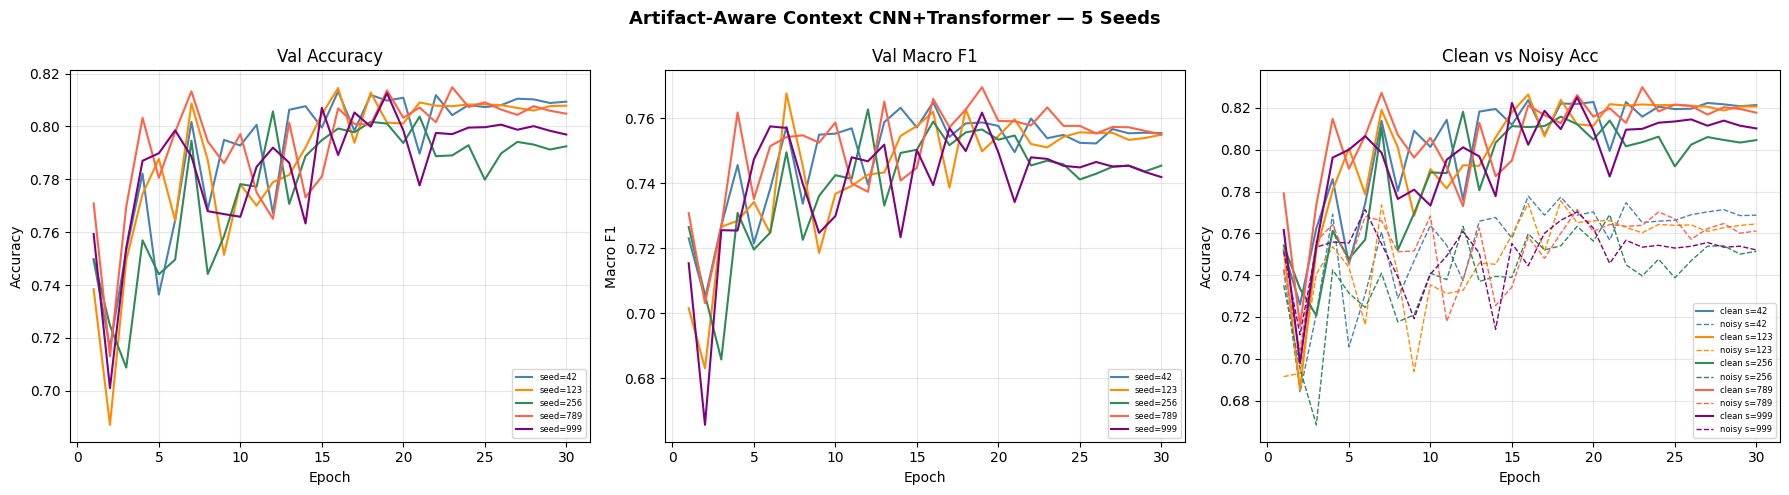

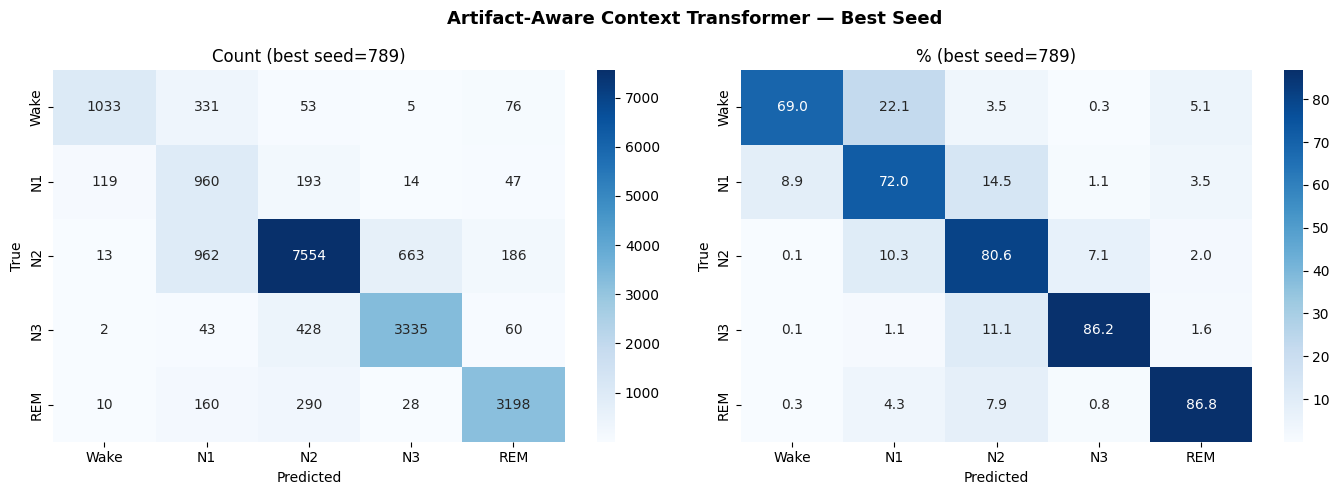

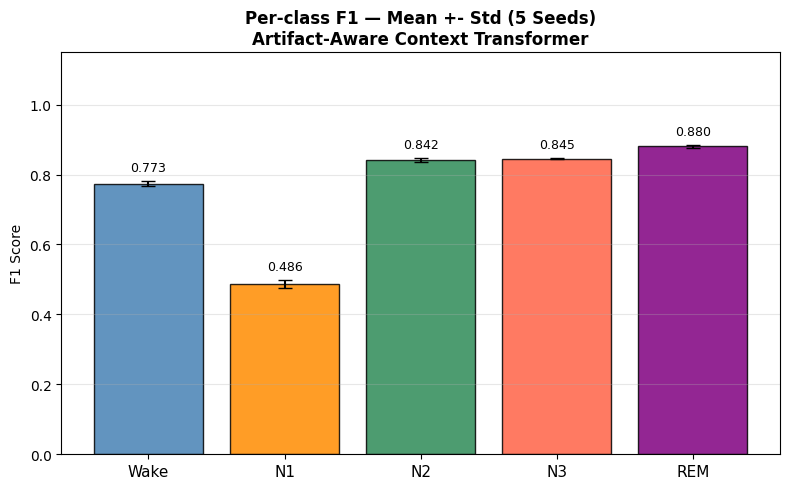

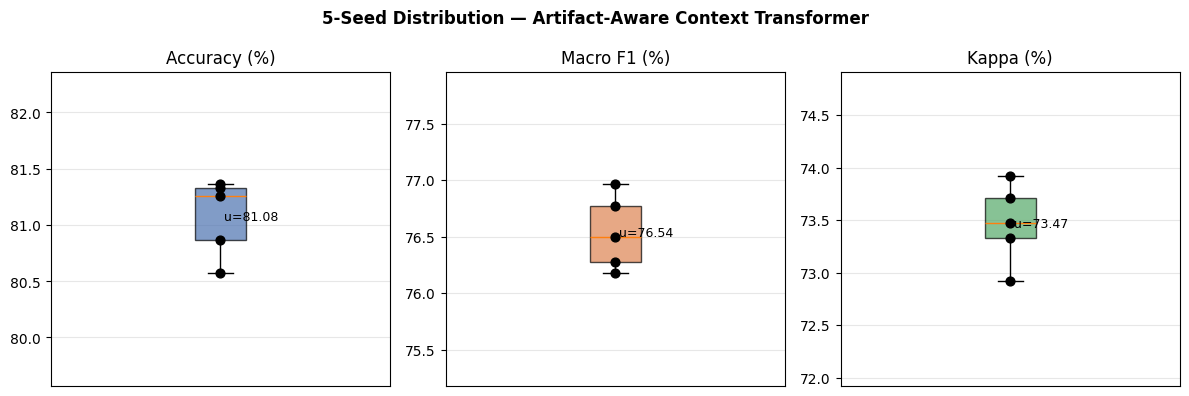


All outputs saved: D:\22\AA\evaluation\4ch_artifact-aware_ContextCnnTransformerF
  best_seed<N>.pt
  all_seeds_epoch_log.csv
  summary.csv
  training_curves_5seeds.png
  confusion_matrix_best_seed.png
  per_class_f1_5seed.png
  boxplot_5seeds.png
Done!


In [1]:
# ============================================================
# Artifact-Aware Context CNN + Transformer
# Document 9 এর উপর artifact weighting যোগ করা হয়েছে
#4 channelsCHANNELS_EEG = ["PSG_F3:A2", "PSG_C3:A2"]   # 2 EEG
# CHANNELS_EOG = ["PSG_EOG1:A2", "PSG_EOG2:A2"]  # 2 EOG
# Key changes from plain Context CNN+Transformer:
#   1. TSV থেকে per-epoch artifact weight load
#   2. artifact_weighted_loss — clean epoch থেকে বেশি শেখে
#   3. weight=0.0 → no data epoch → loss=0 (ignore)
#   4. weight=1.0 → clean epoch → full loss
#   5. evaluate এ clean vs noisy accuracy আলাদা দেখায়
#   6. Fixed split (seed=42) — সব seed এ same train/test
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\4ch_artifact-aware_ContextCnnTransformerF"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 3
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Seeds  : {SEEDS}")
print(f"Output : {EVAL_PATH}")

# ============================================================
# ARTIFACT WEIGHT CONFIG
# TSV score → loss weight mapping
# 0 = clean      → 1.0 (পুরো loss নাও)
# 1 = no data    → 0.0 (ignore, gradient নেই)
# 2 = high noise → 0.4 (40% loss)
# 3 = spiky      → 0.2 (20% loss)
# 4 = M-shaped   → 0.1 (10% loss)
# ============================================================
ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}

# TSV এ EEG channel columns
TARGET_CHANNELS  = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None

    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)

    # ✅ FIX: offset দিয়ে epoch index বানাও (onset এ 0.003906 offset আছে)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)

    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    n_epochs = int(epoch_scores.index.max()) + 1
    weights  = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)

    return weights


# ============================================================
# SUBJECT SPLIT — FIXED (seed=42, সব model এ same)
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# DATASET — Artifact-Aware, Full RAM Loading
# ============================================================
class ArtifactAwareDataset(Dataset):
    """
    প্রতিটা sample এ (x, y, weight) return করে।
    weight = artifact quality score থেকে আসা float (0.0 ~ 1.0)
    Context window: center epoch ± CONTEXT epochs
    """
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []    # (signal, labels) list
        self.index   = []    # (sub_idx, center_i, n, weight)

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue

            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]   # (N, 2, 3000)
                eog    = d['eog'][:, [0, 1],    :]   # (N, 3, 3000)
                signal = np.concatenate(
                    [eeg, eog], axis=1
                ).astype(np.float32)               # (N, 3, 3000)
                labels = d['labels'].copy()

            n = len(labels)

            # Artifact weights load
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                # Length align
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    pad   = np.ones(n - len(art_w), dtype=np.float32)
                    art_w = np.concatenate([art_w, pad])

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)],
            dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects (weight=1.0 default)")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        # Context window (boundary clamping)
        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)    # (WINDOW, 3, 3000)
        y = int(labels[center_i])

        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


# Dataset build — একবার, সব seed এ same
print("\nBuilding datasets (once for all seeds)...")
train_ds = ArtifactAwareDataset(TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH)
print()
test_ds  = ArtifactAwareDataset(TEST_SUBS,  SAVE_PATH, ARTIFACT_PATH)
print("Datasets ready.")


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# MODEL — Context CNN + Transformer (same as before)
# ============================================================
class ContextCNNTransformer(nn.Module):
    def __init__(
        self, in_ch=3, d_model=128, nhead=8,
        num_layers=3, dim_ff=256, dropout=0.4,
        n_classes=5, context=CONTEXT
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            intra_seq = self.epoch_cnn(
                torch.zeros(1, in_ch, 3000)
            ).shape[2]

        self.intra_pos = PositionalEncoding(
            d_model, max_len=intra_seq + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )
        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        feat = self.epoch_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        feat = self.intra_transformer(
            self.intra_pos(feat)
        ).mean(dim=1).view(B, W, self.d_model)
        feat = self.inter_transformer(self.inter_pos(feat))
        return self.classifier(feat[:, self.context, :])


# ============================================================
# ARTIFACT-WEIGHTED LOSS
# ============================================================
def artifact_weighted_loss(logits, labels, weights, class_weights):
    """
    Per-sample artifact weight দিয়ে loss scale করো।
    weight=1.0 → clean → পুরো loss
    weight=0.0 → no data → loss=0 (gradient নেই)
    weight=0.4 → noisy → 40% loss
    """
    ce_loss  = nn.CrossEntropyLoss(
        weight=class_weights, reduction='none'
    )(logits, labels)                    # (batch,)

    weighted = ce_loss * weights         # (batch,)

    # weight=0 sample গুলো mean এ count করবো না
    valid = weights > 0
    if valid.sum() == 0:
        return weighted.mean()
    return weighted[valid].mean()


# ============================================================
# CLASS WEIGHTS — train dataset থেকে compute
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights (from train data):")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ============================================================
# TRAIN / EVAL FUNCTIONS
# ============================================================
def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = artifact_weighted_loss(out, y, w, cw)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)

    # Clean vs Noisy accuracy (paper এ useful)
    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)

    clean_acc = accuracy_score(
        labs[clean_mask], preds[clean_mask]
    ) if clean_mask.sum() > 0 else 0.0
    noisy_acc = accuracy_score(
        labs[noisy_mask], preds[noisy_mask]
    ) if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV LOG SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa',
        'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []
all_cms          = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    model = ContextCNNTransformer(in_ch=4).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    optimizer    = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch,
            'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
            'vl_acc': vl_acc,   'vl_f1': vl_f1,   'vl_kap': vl_kap,
            'clean_acc': clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f} TrAcc:{tr_acc:.3f} "
            f"ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
            f"k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        # Epoch CSV
        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval with best checkpoint
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    fin_cm = confusion_matrix(fin_labels, fin_preds)
    all_cms.append(fin_cm)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy      : {fin_acc*100:.2f}%")
    print(f"  Macro F1      : {fin_f1:.4f}")
    print(f"  Cohen Kappa   : {fin_kap:.4f}")
    print(f"  Clean Acc     : {fin_clean_acc*100:.2f}% ({fin_n_clean} epochs)")
    print(f"  Noisy Acc     : {fin_noisy_acc*100:.2f}% ({fin_n_noisy} epochs)")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed':       seed,
        'acc':        fin_acc,
        'f1':         fin_f1,
        'kappa':      fin_kap,
        'per_cls':    fin_per,
        'clean_acc':  fin_clean_acc,
        'noisy_acc':  fin_noisy_acc,
        'n_clean':    fin_n_clean,
        'n_noisy':    fin_n_noisy,
        'preds':      fin_preds,
        'labels':     fin_labels,
        'history':    history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed":      seed,
            "acc":       round(fin_acc,  4),
            "f1_macro":  round(fin_f1,   4),
            "kappa":     round(fin_kap,  4),
            "f1_Wake":   round(fin_per[0], 4),
            "f1_N1":     round(fin_per[1], 4),
            "f1_N2":     round(fin_per[2], 4),
            "f1_N3":     round(fin_per[3], 4),
            "f1_REM":    round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT — Mean ± Std
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"{'='*60}")

accs   = np.array([r['acc']   for r in all_seed_results]) * 100
f1s    = np.array([r['f1']    for r in all_seed_results])
kappas = np.array([r['kappa'] for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])
c_accs = np.array([r['clean_acc'] for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc'] for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} "
          f"{r['acc']*100:>7.2f} "
          f"{r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} "
          f"{r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} "
          f"{r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} "
      f"{accs.mean():>7.2f} "
      f"{f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} "
      f"{n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} "
      f"{n_accs.mean():>10.2f}")
print(f"{'Std':<8} "
      f"{accs.std():>7.2f} "
      f"{f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} "
      f"{n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} "
      f"{n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} +- {n1s.std():.4f}")

print(f"\nPer-class F1 (mean +- std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} +- {vals.std():.4f}")

# Summary CSV mean/std rows
with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean",
                "acc":       round(accs.mean()/100, 4),
                "f1_macro":  round(f1s.mean(),    4),
                "kappa":     round(kappas.mean(),  4),
                "f1_Wake":   round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})
    w.writerow({"seed": "std",
                "acc":       round(accs.std()/100, 4),
                "f1_macro":  round(f1s.std(),    4),
                "kappa":     round(kappas.std(),  4),
                "f1_Wake":   round(np.std([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.std([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.std([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.std([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.std([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.std()/100, 4),
                "noisy_acc": round(n_accs.std()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")


# ============================================================
# PLOTS
# ============================================================
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

# 1. Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r, c in zip(all_seed_results, colors):
    h   = r['history']
    eps = [x['epoch'] for x in h]
    axes[0].plot(eps, [x['vl_acc']      for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[1].plot(eps, [x['vl_f1']       for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[2].plot(eps, [x['clean_acc']   for x in h], color=c, lw=1.5, ls='-',  label=f"clean s={r['seed']}")
    axes[2].plot(eps, [x['noisy_acc']   for x in h], color=c, lw=1.0, ls='--', label=f"noisy s={r['seed']}")

for ax, title, ylabel in zip(
    axes,
    ["Val Accuracy", "Val Macro F1", "Clean vs Noisy Acc"],
    ["Accuracy", "Macro F1", "Accuracy"]
):
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel); ax.legend(fontsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Artifact-Aware Context CNN+Transformer — 5 Seeds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"), dpi=150)
plt.show()

# 2. Confusion matrix (best seed)
best_r  = max(all_seed_results, key=lambda r: r['f1'])
cm      = confusion_matrix(best_r['labels'], best_r['preds'])
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count (best seed={best_r['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% (best seed={best_r['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("Artifact-Aware Context Transformer — Best Seed",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()

# 3. Per-class F1
per_means = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).mean(axis=1)
per_stds  = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(np.arange(5), per_means, yerr=per_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(np.arange(5)); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1 — Mean +- Std (5 Seeds)\nArtifact-Aware Context Transformer",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, per_means, per_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
            f"{m:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=150)
plt.show()

# 4. Box plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (vals, title, color) in zip(axes, [
    (accs,      "Accuracy (%)",  '#4C72B0'),
    (f1s*100,   "Macro F1 (%)",  '#DD8452'),
    (kappas*100,"Kappa (%)",     '#55A868'),
]):
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.scatter([1]*len(vals), vals, color='black', zorder=5, s=40)
    ax.set_title(title); ax.set_xticks([]); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(vals.min()-1, vals.max()+1)
    ax.text(1, vals.mean(), f" u={vals.mean():.2f}", va='center', fontsize=9)

fig.suptitle("5-Seed Distribution — Artifact-Aware Context Transformer",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "boxplot_5seeds.png"), dpi=150)
plt.show()

# ============================================================
print(f"\n{'='*60}")
print(f"All outputs saved: {EVAL_PATH}")
print(f"  best_seed<N>.pt")
print(f"  all_seeds_epoch_log.csv")
print(f"  summary.csv")
print(f"  training_curves_5seeds.png")
print(f"  confusion_matrix_best_seed.png")
print(f"  per_class_f1_5seed.png")
print(f"  boxplot_5seeds.png")
print(f"{'='*60}")
print("Done!")